# Taxi Fare Prediction using Machine Learning

### Project Objective

The objective of this project is to build a machine learning model that accurately predicts taxi fare prices based on trip information such as distance, time, weather, traffic conditions, passenger count, and location.

The project includes:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Model evaluation
- Hyperparameter tuning
- Model comparison

## Import Required Libraries

Import all the libraries needed for data manipulation, visualization, preprocessing, model training, evaluation, and saving the final model.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

## Load the Dataset

Load the cleaned Uber dataset and display the first few rows to understand its structure.

In [2]:
df = pd.read_csv("cleaned_uber_data.csv")

df.head()


,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,3,4,0,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,1,0,2,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,0,2,0,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,3,2,2,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,0,2,0,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


## Dataset Overview

Inspect the dataset by checking:
- Dataset shape
- Data types
- Missing values

This helps verify that the dataset is ready for machine learning.

In [3]:
# Dataset Overview

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape: (456666, 22)

Data Types:
Car Condition          int64
Weather                int64
Traffic Condition      int64
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
hour                   int64
day                    int64
month                  int64
weekday                int64
year                   int64
jfk_dist             float64
ewr_dist             float64
lga_dist             float64
sol_dist             float64
nyc_dist             float64
distance             float64
bearing              float64
dtype: object

Missing Values:
Car Condition        0
Weather              0
Traffic Condition    0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month         

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,3,4,0,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,1,0,2,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,0,2,0,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,3,2,2,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,0,2,0,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


## Feature Engineering

Create additional features that may improve the model performance.

New features:
- Weekend trips
- Night trips
- Rush hour trips

In [4]:
# Feature Engineering


# Weekend Feature
df["is_weekend"] = df["weekday"].isin([5,6]).astype(int)

# Night Trips
df["is_night"] = (
    (df["hour"] >= 22) |
    (df["hour"] <= 5)
).astype(int)

# Rush Hour Trips
df["is_rush_hour"] = df["hour"].isin(
    [7,8,9,16,17,18]
).astype(int)

df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,is_weekend,is_night,is_rush_hour
0,3,4,0,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897,0,0,1
1,1,0,2,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217,0,0,1
2,0,2,0,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961,0,1,0
3,3,2,2,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905,1,1,0
4,0,2,0,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703,0,0,1


In [5]:
# Remove Unnecessary Features
# Remove columns that do not contribute to predicting the taxi fare such as IDs and timestamps.

columns_to_drop = []

if "pickup_datetime" in df.columns:
    columns_to_drop.append("pickup_datetime")

if "User ID" in df.columns:
    columns_to_drop.append("User ID")

if "User Name" in df.columns:
    columns_to_drop.append("User Name")

if "Driver Name" in df.columns:
    columns_to_drop.append("Driver Name")

if "key" in df.columns:
    columns_to_drop.append("key")

df.drop(columns=columns_to_drop, inplace=True)

print(df.columns)

Index(['Car Condition', 'Weather', 'Traffic Condition', 'fare_amount',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing', 'is_weekend', 'is_night',
       'is_rush_hour'],
      dtype='str')


## Separate Features and Target

Split the dataset into:

- Features (X)
- Target variable (Fare Amount)

In [6]:
# Separate Features and Target


X = df.drop("fare_amount", axis=1)

y = df["fare_amount"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (456666, 23)
Target Shape: (456666,)


In [7]:
# Check Feature Data Types
# Verify that all features are numerical before training machine learning models.

print(X.dtypes)

Car Condition          int64
Weather                int64
Traffic Condition      int64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
hour                   int64
day                    int64
month                  int64
weekday                int64
year                   int64
jfk_dist             float64
ewr_dist             float64
lga_dist             float64
sol_dist             float64
nyc_dist             float64
distance             float64
bearing              float64
is_weekend             int64
is_night               int64
is_rush_hour           int64
dtype: object


## Feature Selection

Evaluate the relationship between each feature and the target variable using SelectKBest with the F-test score.

Higher scores indicate stronger linear relationships.

In [8]:
# Feature Selection


selector = SelectKBest(
    score_func=f_regression,
    k="all"
)

selector.fit(X, y)

scores = pd.DataFrame({

    "Feature": X.columns,

    "Score": selector.scores_

})

scores = scores.sort_values(
    by="Score",
    ascending=False
)

scores

,Feature,Score
12,year,8566.794017
21,is_night,1723.280926
10,month,365.206931
22,is_rush_hour,321.264408
11,weekday,196.633156
9,day,196.633156
7,passenger_count,99.481055
19,bearing,78.310220
8,hour,59.280390
20,is_weekend,40.934497


C:\Users\ahmed\AppData\Local\Temp\ipykernel_12692\3499972492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


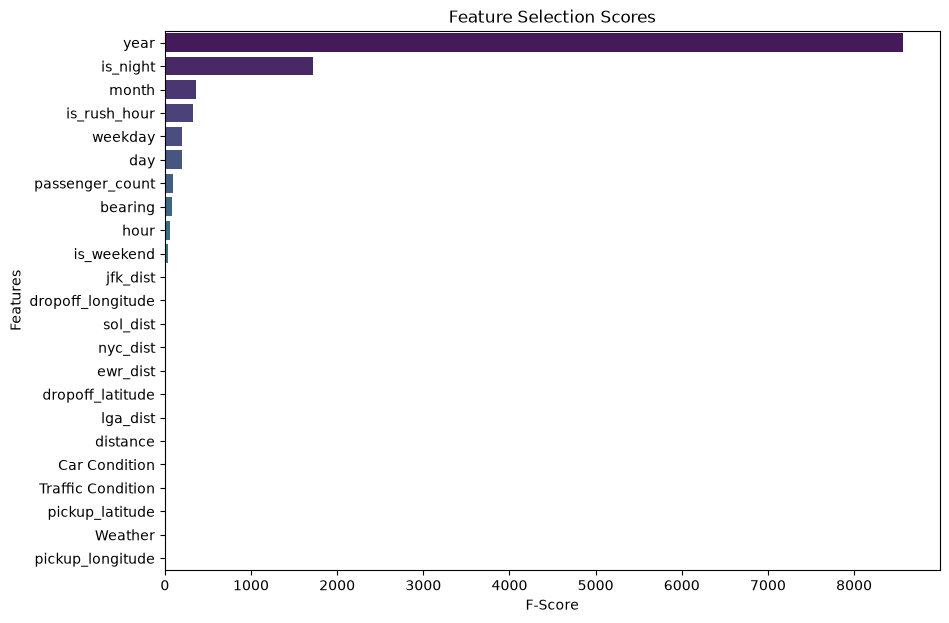

In [9]:
# Plot Feature Scores


plt.figure(figsize=(10,7))

sns.barplot(

    data=scores,

    y="Feature",

    x="Score",

    palette="viridis"

)

plt.title("Feature Selection Scores")

plt.xlabel("F-Score")

plt.ylabel("Features")

plt.show()

## Feature Scaling

Standardize the features using StandardScaler to improve the performance of machine learning algorithms.

In [10]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Car Condition,Weather,Traffic Condition,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,...,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,is_weekend,is_night,is_rush_hour
0,1.340944,1.415494,-1.224301,-0.109115,0.116098,-0.109662,0.105362,-0.520406,0.530205,-1.563568,...,-0.150187,-0.132609,-0.143139,-0.134232,-0.133878,-0.046344,-1.790994,-0.629471,-0.547697,1.600433
1,-0.447093,-1.414229,1.225052,-0.123509,0.114614,-0.121309,0.114728,-0.520406,0.376486,-1.049748,...,-0.140044,-0.142272,-0.139496,-0.142271,-0.141668,-0.025164,-0.383502,-0.629471,-0.547697,1.600433
2,-1.341112,0.000632,-1.224301,-0.120717,0.122019,-0.122322,0.110504,0.245946,-2.083022,-0.022109,...,-0.140489,-0.141494,-0.140849,-0.141196,-0.141216,-0.045320,1.262751,-0.629471,1.825826,-0.624831
3,1.340944,0.000632,1.225052,-0.121085,0.117850,-0.122350,0.111516,-0.520406,-1.468145,1.005530,...,-0.140886,-0.141972,-0.140353,-0.142017,-0.142103,-0.041296,-0.101790,1.588637,1.825826,-0.624831
4,-1.341112,0.000632,-1.224301,-0.119490,0.123017,-0.119396,0.114964,-0.520406,-1.006987,-1.049748,...,-0.140600,-0.139136,-0.142776,-0.138708,-0.138834,-0.043580,-0.454044,-0.629471,-0.547697,1.600433


## Train-Test Split

- 80% Training
- 20% Testing

In [11]:
# Split Dataset


X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (365332, 23)
Testing Shape: (91334, 23)


## Linear Regression Model

In [12]:
# Train Linear Regression


lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
# Linear Regression Evaluation


print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test, lr_pred)
))

print("R2 :", r2_score(
    y_test,
    lr_pred
))

MAE : 3.121298950107724
RMSE : 3.9556923425081845
R2 : 0.08147937734832911


## Cross Validation

Use 5-Fold Cross Validation to measure the model's ability to generalize to unseen data.

In [14]:
# Cross Validation

scores = cross_val_score(

    lr,

    X_scaled,

    y,

    cv=5,

    scoring="r2"

)

print(scores)

print()

print("Average R2:", scores.mean())

[0.0803304  0.0751418  0.07844414 0.08399625 0.07353876]

Average R2: 0.07829026935733918


## Decision Tree Regressor

In [15]:
# Train Decision Tree Model


tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

In [16]:
# Decision Tree Evaluation


tree_mae = mean_absolute_error(y_test, tree_pred)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_r2 = r2_score(
    y_test,
    tree_pred
)

print("Decision Tree Results:")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Results:
MAE : 1.8231730790286202
RMSE: 2.7924719739299957
R²  : 0.5422571760783566


## Random Forest Regressor

In [17]:
# Train Random Forest Model


forest = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

In [18]:
# Random Forest Evaluation


forest_mae = mean_absolute_error(
    y_test,
    forest_pred
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_pred
    )
)

forest_r2 = r2_score(
    y_test,
    forest_pred
)

print("Random Forest Results:")
print("MAE :", forest_mae)
print("RMSE:", forest_rmse)
print("R²  :", forest_r2)

Random Forest Results:
MAE : 1.2809326299495205
RMSE: 1.9224210231018772
R²  : 0.7830593621912167


In [19]:
# Cross Validation


cv_scores = cross_val_score(

    forest,

    X_scaled,

    y,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average R² :", cv_scores.mean())

Cross Validation Scores
[0.78139504 0.77873716 0.78061623 0.78396563 0.78077637]

Average R² : 0.7810980873215005


## Create a Training Sample

Use a random subset of the training data to reduce the computational cost of hyperparameter tuning.

In [20]:
# Take a Random Sample for Faster Tuning


X_sample = X_train.sample(
    n=50000,
    random_state=42
)

y_sample = y_train.loc[X_sample.index]

print("Sample Shape:", X_sample.shape)

Sample Shape: (50000, 23)


## Hyperparameter Tuning

Optimize the Random Forest model using RandomizedSearchCV.

Randomized Search is used because it significantly reduces computation time while still finding high-performing parameter combinations.

In [21]:
# Hyperparameter Tuning


param_dist = {

    "n_estimators": [100, 150, 200],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

random_search = RandomizedSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_distributions=param_dist,

    n_iter=10,

    cv=3,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

random_search.fit(
    X_sample,
    y_sample
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multip

## Best Hyperparameters

Display the best parameter combination and the best cross-validation score.

In [22]:
# Best Parameters

print("Best Parameters:")
print(random_search.best_params_)

print()

print("Best Cross Validation Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30}

Best Cross Validation Score:
0.7590485536342021


## Train the Optimized Model

Train a new Random Forest model using the optimal hyperparameters found during tuning.

In [23]:
# Train Final Random Forest

best_model = RandomForestRegressor(

    **random_search.best_params_,

    random_state=42,

    n_jobs=-1

)

best_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [24]:
# Predict Test Data

best_pred = best_model.predict(
    X_test
)

In [25]:
# Final Model Evaluation


mae = mean_absolute_error(
    y_test,
    best_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
)

r2 = r2_score(
    y_test,
    best_pred
)

print("Final Random Forest Results")
print("----------------------------")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Final Random Forest Results
----------------------------
MAE  : 1.255
RMSE : 1.901
R²   : 0.788


## Feature Importance

Identify the most influential features used by the Random Forest model to predict taxi fares.

In [26]:
# Feature Importance


importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
18,distance,0.747635
12,year,0.042533
19,bearing,0.040412
8,hour,0.022198
13,jfk_dist,0.018356
6,dropoff_latitude,0.016701
10,month,0.014087
5,dropoff_longitude,0.012202
3,pickup_longitude,0.012092
4,pickup_latitude,0.010811


C:\Users\ahmed\AppData\Local\Temp\ipykernel_12692\2644937805.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


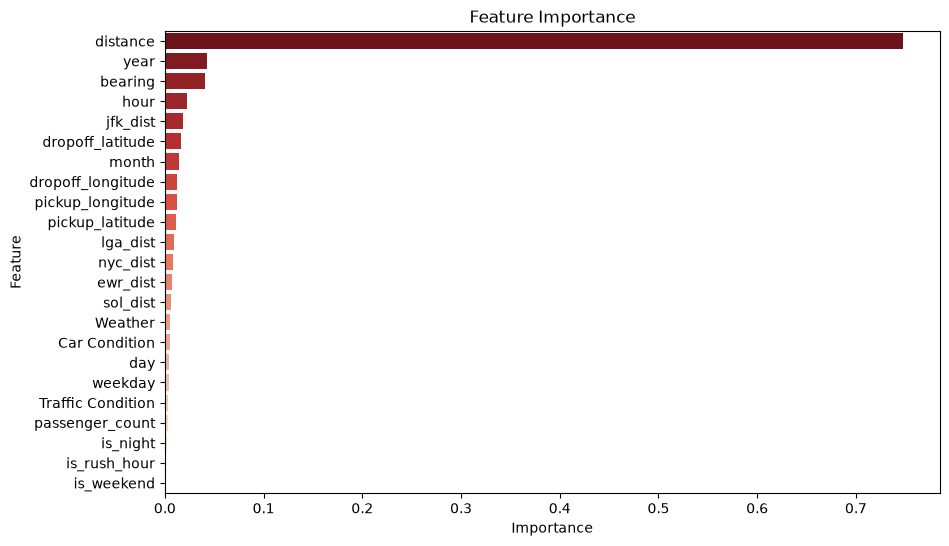

In [27]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="Reds_r"

)

plt.title("Feature Importance")

plt.show()

## Actual vs Predicted Values

Compare the predicted taxi fares with the actual fares.

Points closer to the red diagonal line indicate better predictions.

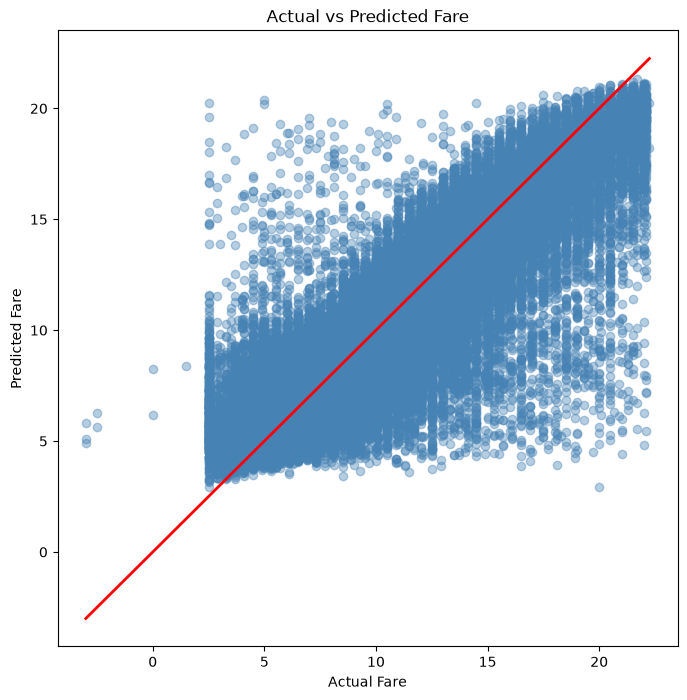

In [28]:
plt.figure(figsize=(8,8))

plt.scatter(

    y_test,

    best_pred,

    alpha=0.4,

    color="steelblue"

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Fare")

plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare")

plt.show()

## Residual Analysis

Analyze the prediction errors.

A good model should produce residuals that are randomly distributed around zero.



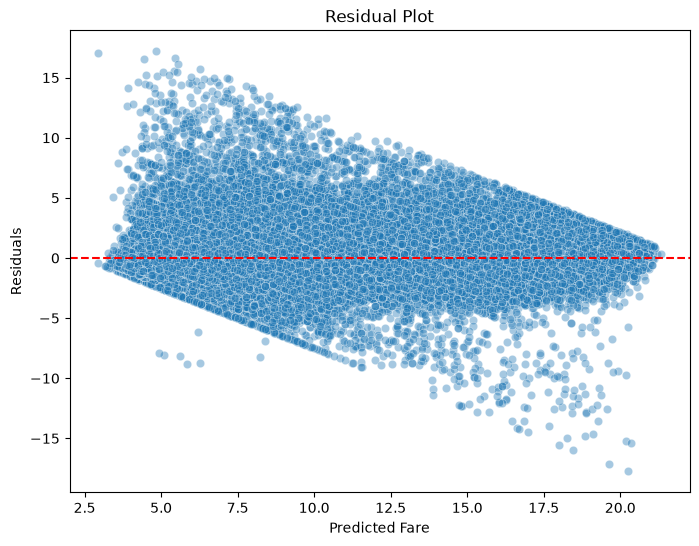

In [29]:
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.scatterplot(

    x=best_pred,

    y=residuals,

    alpha=0.4

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Fare")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Residual Distribution

Visualize the distribution of prediction errors.

Ideally, residuals should be centered around zero and approximately normally distributed.

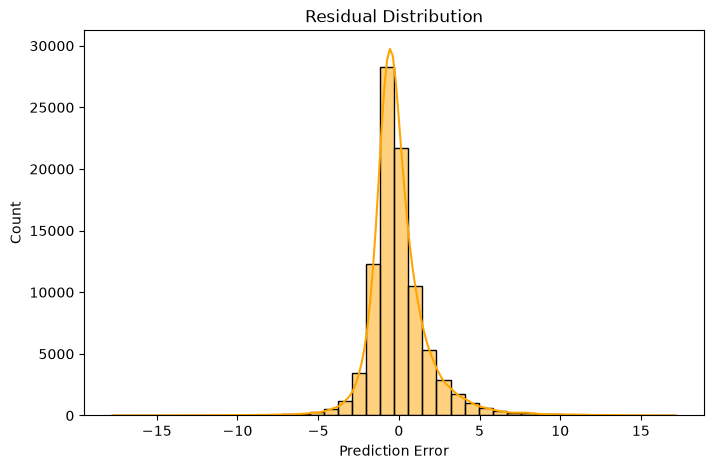

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(

    residuals,

    bins=40,

    kde=True,

    color="orange"

)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

## Model Comparison

In [31]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Tuned Random Forest"

    ],

    "MAE":[

        mean_absolute_error(y_test,lr_pred),

        mean_absolute_error(y_test,tree_pred),

        mean_absolute_error(y_test,forest_pred),

        mean_absolute_error(y_test,best_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test,lr_pred)),

        np.sqrt(mean_squared_error(y_test,tree_pred)),

        np.sqrt(mean_squared_error(y_test,forest_pred)),

        np.sqrt(mean_squared_error(y_test,best_pred))

    ],

    "R²":[

        r2_score(y_test,lr_pred),

        r2_score(y_test,tree_pred),

        r2_score(y_test,forest_pred),

        r2_score(y_test,best_pred)

    ]

})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,3.121299,3.955692,0.081479
1,Decision Tree,1.823173,2.792472,0.542257
2,Random Forest,1.280933,1.922421,0.783059
3,Tuned Random Forest,1.255126,1.900906,0.787888


C:\Users\ahmed\AppData\Local\Temp\ipykernel_12692\2694093203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


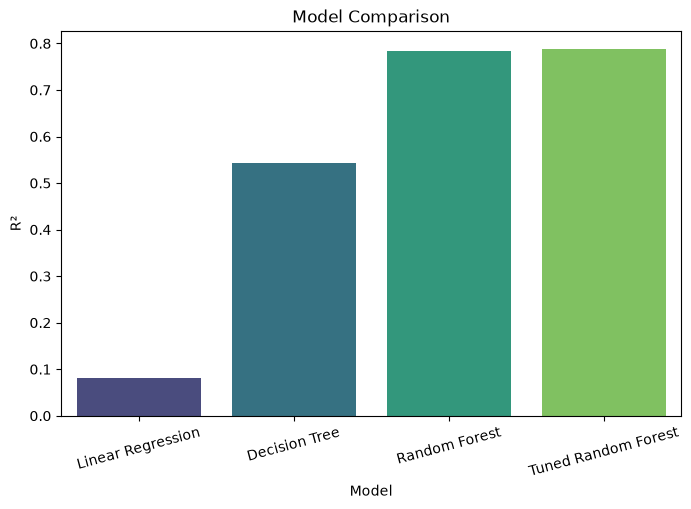

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=comparison,

    x="Model",

    y="R²",

    palette="viridis"

)

plt.xticks(rotation=15)

plt.title("Model Comparison")

plt.show()

In [33]:
# import joblib

# joblib.dump(

#     best_model,

#     "TaxiFarePredictionModel.pkl"

# )

# print("Model Saved Successfully!")

# joblib.dump(
#     scaler,
#     "TaxiFareScaler.pkl"
# )

# print("Scaler Saved Successfully!") 

import joblib

joblib.dump(
    best_model,
    "TaxiFarePredictionModel.pkl",
    compress=3
)

print("Model Saved Successfully!")

joblib.dump(
    scaler,
    "TaxiFareScaler.pkl",
    compress=3
)

print("Scaler Saved Successfully!")

Model Saved Successfully!
Scaler Saved Successfully!


In [34]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)

print("Predicted Fare:", prediction[0])

print("Actual Fare:", y_test.iloc[0])

Predicted Fare: 4.991195915195914
Actual Fare: 4.5


# Final Conclusion

### Summary

- The dataset was successfully cleaned and prepared.
- Feature engineering was applied to improve model performance.
- Multiple regression models were trained and evaluated.
- Hyperparameter tuning improved the Random Forest model.
- Feature importance analysis showed that distance-related features are the most influential.
- The tuned Random Forest achieved the highest predictive performance.

### Future Work

- Collect additional data.
- Experiment with advanced boosting models such as XGBoost or LightGBM.
- Deploy the model as a web application for real-time fare prediction.